In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.datasets import load_iris

In [2]:
X = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)

In [3]:
# Normalize and reduce dimensions
X_scaled = StandardScaler().fit_transform(X)
X_normalized = normalize(X_scaled)
X_pca = pd.DataFrame(PCA(n_components=2).fit_transform(X_normalized), columns=['P1','P2'])

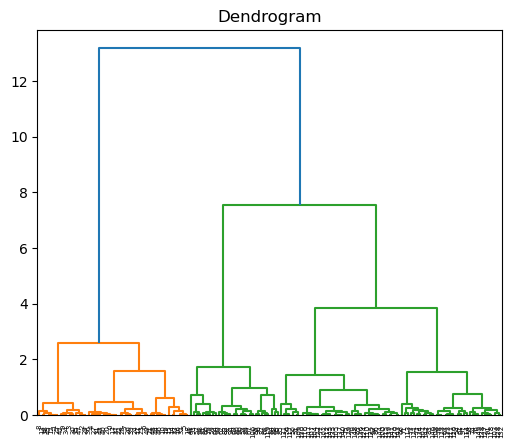

In [4]:
# Dendrogram
plt.figure(figsize=(6,5))
plt.title("Dendrogram")
shc.dendrogram(shc.linkage(X_pca, method='ward'))
plt.show()

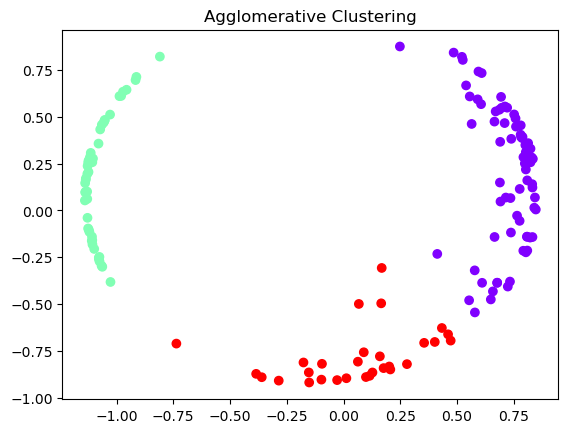

In [5]:
model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X_pca)
plt.scatter(X_pca['P1'], X_pca['P2'], c=labels, cmap='rainbow')
plt.title("Agglomerative Clustering")
plt.show()


In [6]:
score = silhouette_score(X_pca, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.6467566105491777
